In [1]:
import numpy as np
import scipy
from scipy.interpolate import interp1d
import pyspk as spk

In [2]:
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt

In [3]:
cosmo = FlatLambdaCDM(H0 = 67.32, Om0 = 0.3)
alpha = 4.189
beta = 1.273
gamma = 0.298

In [4]:
k_spk, sup = spk.sup_model(SO=500, z = 0.3, alpha = alpha, beta = beta, gamma = gamma, cosmo = cosmo, k_min = 0.001, verbose = True)

Using an Akino et al. 2022 power-law fit for fb - M_halo at z=0.300. 


In [5]:
print(k_spk)

[1.000000e-03 1.095000e-03 1.199000e-03 1.313000e-03 1.438000e-03
 1.574000e-03 1.724000e-03 1.888000e-03 2.067000e-03 2.264000e-03
 2.479000e-03 2.714000e-03 2.972000e-03 3.255000e-03 3.564000e-03
 3.903000e-03 4.274000e-03 4.680000e-03 5.125000e-03 5.611000e-03
 6.145000e-03 6.729000e-03 7.368000e-03 8.068000e-03 8.835000e-03
 9.675000e-03 1.059400e-02 1.160100e-02 1.270300e-02 1.391000e-02
 1.523200e-02 1.667900e-02 1.826400e-02 2.000000e-02 2.190100e-02
 2.398200e-02 2.626100e-02 2.875600e-02 3.148900e-02 3.448100e-02
 3.775800e-02 4.134600e-02 4.527500e-02 4.957700e-02 5.428800e-02
 5.944700e-02 6.509600e-02 7.128200e-02 7.805600e-02 8.547400e-02
 9.359600e-02 1.024900e-01 1.122300e-01 1.228950e-01 1.345730e-01
 1.473610e-01 1.613650e-01 1.766990e-01 1.934900e-01 2.118770e-01
 2.320110e-01 2.540590e-01 2.782010e-01 3.046380e-01 3.335870e-01
 3.652880e-01 4.000000e-01 4.380110e-01 4.796340e-01 5.252130e-01
 5.751230e-01 6.297750e-01 6.896220e-01 7.551550e-01 8.269160e-01
 9.054960e

In [6]:
print(sup)

[1.00000014 1.00000016 1.00000019 1.00000022 1.00000025 1.00000029
 1.00000034 1.0000004  1.00000046 1.00000053 1.00000062 1.00000072
 1.00000083 1.00000096 1.00000112 1.0000013  1.0000015  1.00000175
 1.00000202 1.00000235 1.00000272 1.00000316 1.00000366 1.00000425
 1.00000493 1.00000571 1.00000662 1.00000768 1.00000891 1.00001033
 1.00001198 1.00001388 1.00001609 1.00001864 1.00002159 1.00002499
 1.00002889 1.00003336 1.00003845 1.00004422 1.00005068 1.00005784
 1.00006563 1.0000739  1.00008234 1.00009045 1.00009743 1.00010204
 1.00010247 1.00009608 1.00007919 1.00004676 0.99999196 0.99990589
 0.99977706 0.99959109 0.99933041 0.9989742  0.99849848 0.99787657
 0.99707995 0.99607931 0.99484609 0.99335373 0.99157942 0.98950506
 0.98711845 0.9844132  0.98138907 0.97805128 0.97441006 0.97047966
 0.96627739 0.96182348 0.95713988 0.95225037 0.94718012 0.94195568
 0.93660504 0.93115776 0.92564512 0.92010017 0.91455814 0.90905628
 0.90363406 0.89833325 0.89319776 0.88827354 0.88360831 0.8792

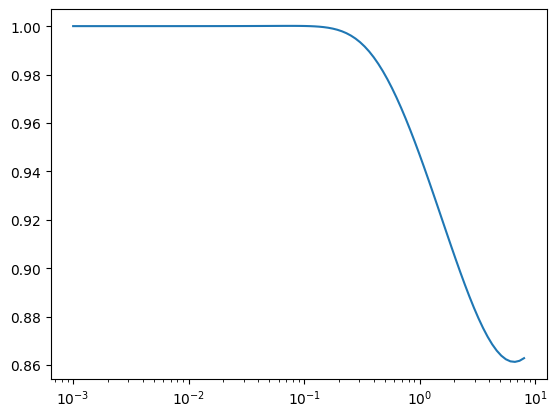

In [7]:
plt.plot(k_spk, sup)
plt.xscale('log')

In [8]:
accboost = 1
log10k_interp_2D = np.linspace(-4.99,2.0,int(1250+250*accboost))

In [9]:
interp_spk = interp1d(np.log10(k_spk), 
                                  np.log10(sup), kind = 'linear', fill_value = 'extrapolate', assume_sorted = True)

In [10]:
lnbt_spk = interp_spk(log10k_interp_2D)

In [11]:
np.max(np.power(10, log10k_interp_2D))

100.0

In [12]:
print(lnbt_spk)

[-4.30746024e-07 -4.29593813e-07 -4.28441602e-07 ... -4.88764088e-02
 -4.88111530e-02 -4.87458971e-02]


In [13]:
min(k_spk)

0.001

In [14]:
lnbt_spk[np.power(10,log10k_interp_2D)<1e-3] = 0

(0.001, 10)

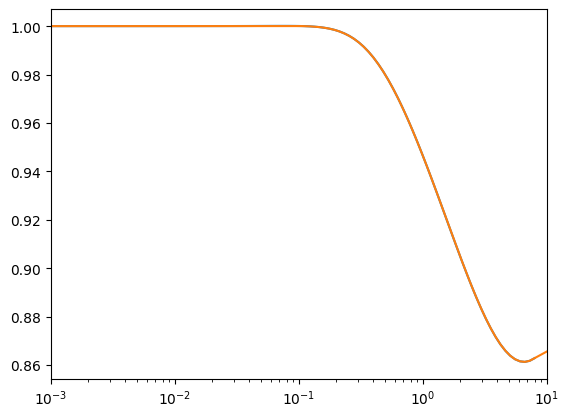

In [15]:
plt.plot(k_spk, sup)
plt.plot(np.power(10, log10k_interp_2D), np.power(10,lnbt_spk))
plt.xscale('log')
plt.xlim(1e-3, 10)

In [16]:
import BCemu

Emulators loaded.
Baryon fraction is set to 0.185
Suppressions modelled at k<0.034 h/Mpc are outside the training set and therefore extrapolated.
Suppressions modelled at k>12.517 h/Mpc are outside the training set and therefore extrapolated.


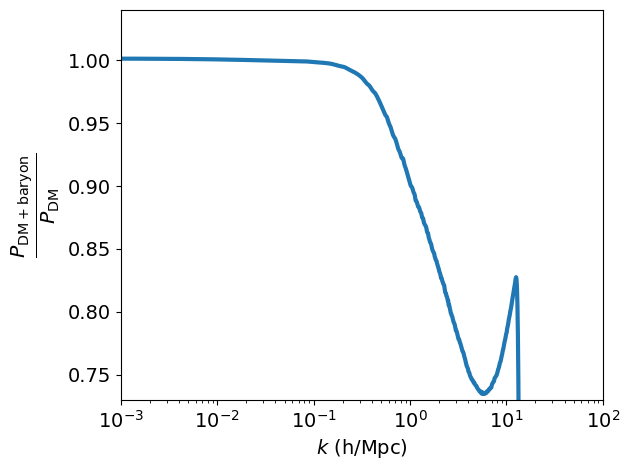

In [20]:
bfcemu = BCemu.BCM_7param(Ob=0.05, Om=0.27)
bcmdict = {'log10Mc': 13.32,
           'mu'     : 0.93,
           'thej'   : 4.235,  
           'gamma'  : 2.25,
           'delta'  : 6.40,
           'eta'    : 0.15,
           'deta'   : 0.14,
           }

z = 1
#k_eval = 10**np.linspace(-1,1.08,50)
k_eval = 10** log10k_interp_2D
p_eval = bfcemu.get_boost(z, bcmdict, k_eval)

plt.semilogx(k_eval, p_eval, c='C0', lw=3)
plt.axis([1e-3,100,0.73,1.04])
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.xlabel(r'$k$ (h/Mpc)', fontsize=14)
plt.ylabel(r'$\frac{P_{\rm DM+baryon}}{P_{\rm DM}}$', fontsize=21)
plt.tight_layout()
plt.show()